---
tags: [integration, optimization, variational]
---

# Using OMMX Quantum Benchmarks (1): Implementing and Benchmarking Quantum Algorithms with Qamomile

This tutorial shows how to run a Qamomile quantum algorithm on a problem
from a public benchmark dataset and compare its solution quality with a
classical solver in the same workflow.

**Goal.** Build a QAOA solver in Qamomile, run it on a
**Low Autocorrelation Binary Sequences (LABS)** instance loaded from the
[OMMX Quantum Benchmarks](https://github.com/Jij-Inc/OmmxQuantumBenchmarks)
dataset, and compare the result with the classical SCIP solver
accessed through the [`ommx-pyscipopt-adapter`](https://github.com/Jij-Inc/ommx-pyscipopt-adapter).
Because both the QAOA path and the SCIP path consume the *same*
`ommx.v1.Instance`, the main difference is the algorithm itself. This
makes the comparison direct.

In [1]:
# Install the additional packages used in this tutorial.
# !pip install qamomile ommx-quantum-benchmarks ommx-pyscipopt-adapter

## What is OMMX Quantum Benchmarks?

**OMMX** ([Open Mathematical prograMming eXchange](https://jij-inc.github.io/ommx/en/introduction.html))
is a data format for exchanging mathematical optimization problems across
tools. Its `ommx.v1.Instance` stores the objective, constraints,
decision-variable metadata, and optional reference solution.

**OMMX Quantum Benchmarks** is a curated collection of optimization
benchmark instances distributed in this `ommx.v1.Instance` format. The
first dataset shipped is **QOBLIB** (Quantum Optimization Benchmarking
Library) [arXiv:2504.03832](https://arxiv.org/abs/2504.03832), which
contains nine problem families used in the recent quantum-optimization
literature, including LABS, Market Split, Independent Set, and
Steiner-tree packing.

Because each benchmark instance is represented as an `ommx.v1.Instance`,
any Qamomile workflow that accepts `ommx.v1.Instance`, including
`QAOAConverter`, can consume these problems without extra adapter code.
The same `Instance` can also be passed to classical OMMX adapters such
as `ommx-pyscipopt-adapter`, so one problem definition can support both
quantum and classical workflows.

## Problem: Low Autocorrelation Binary Sequences (LABS)

**LABS** asks for a binary sequence
$\boldsymbol{s} = (s_0, s_1, \dots, s_{n-1}) \in \{-1, +1\}^n$ whose
off-diagonal autocorrelations

$$
c_k(\boldsymbol{s}) = \sum_{i=0}^{n-k-1} s_i \, s_{i+k},
\qquad k = 1, 2, \dots, n-1
$$

are as close to zero as possible. The benchmark objective is the
**sum of squared autocorrelations**

$$
E(\boldsymbol{s}) = \sum_{k=1}^{n-1} c_k(\boldsymbol{s})^2,
$$

which we want to *minimize*. LABS is NP-hard and has long served as a
stress test for both classical and quantum heuristics.

### Loading a LABS instance

`Labs` exposes two models: `"integer"` (uses integer decision variables
for $c_k$ plus the constraints that tie them to $\boldsymbol{s}$) and
`"quadratic_unconstrained"` (a QUBO reformulation that introduces
auxiliary binary variables $z_{i,k}$ encoding the products
$x_i x_{i+k+1}$ via a quadratic penalty). The QUBO form is the natural
target for QAOA, so we use it here.

In [2]:
from ommx_quantum_benchmarks.qoblib import Labs

dataset = Labs()
print(f"Dataset:           {dataset.name}")
print(f"Available models:  {dataset.model_names}")
print(f"Instance count:    {len(dataset.available_instances['quadratic_unconstrained'])}")
print(f"First 5 instances: {dataset.available_instances['quadratic_unconstrained'][:5]}")

Dataset:           02_labs
Available models:  ['integer', 'quadratic_unconstrained']
Instance count:    99
First 5 instances: ['labs002', 'labs003', 'labs004', 'labs005', 'labs006']


We pick `labs005`, the $n=5$ instance. The QUBO reformulation
uses $n + n(n-1) = 25$ binary variables (5 sequence bits
$x_i$ plus $n(n-1) = 20$ auxiliary $z_{i,k}$ bits). After
`Instance.to_qubo()` folds the penalty terms into the objective
and inactive variables are pruned, this becomes a 15-qubit problem:
small enough to simulate locally, but large enough that QAOA is
non-trivial.

In [3]:
instance, reference_solution = dataset("quadratic_unconstrained", "labs005")
n = 5

print(f"OMMX variables:    {instance.num_variables}")
print(f"OMMX constraints:  {instance.num_constraints}")
print(f"Reference E(s):    {reference_solution.objective}")
print(f"Reference feasible: {reference_solution.feasible}")

[2026-05-27 13:24:35] 🚀 Starting experiment 'qoblib_v2'


[2026-05-27 13:24:35]   ├─ 📊 Environment: OS: Darwin 25.5.0, CPU: Apple M5 (10 cores), Memory: 32.0 GB, Python: 3.11.15


[2026-05-27 13:24:35]   ├─ 📊 Environment Information


[2026-05-27 13:24:35]       ├─ OS: Darwin 25.5.0


[2026-05-27 13:24:35]       ├─ Platform: macOS-26.5-arm64-arm-64bit


...

[2026-05-27 13:24:35]       ├─ Architecture: arm64


[2026-05-27 13:24:35]       ├─ Python: 3.11.15


[2026-05-27 13:24:35]       ├─ Virtual Environment: /Users/yuichironakano/マイドライブ/40_Qamomile/docs-ommx-benchmark/.venv


[2026-05-27 13:24:35]       ├─ Key Package Versions:


OMMX variables:    25
OMMX constraints:  0
Reference E(s):    2.0
Reference feasible: True


The bundled reference solution gives the known optimum
$E^\star = 2$ for $n=5$. We will compare both QAOA and SCIP
against this value.

## Algorithm: QAOA

Rather than use the high-level `QAOAConverter`, we build the
QAOA workflow from scratch with `@qkernel`, following the recipe in
[QAOA for MaxCut: Building the Circuit from Scratch](../algorithm/qaoa_maxcut).
Refer to that tutorial for the gate-by-gate derivation; here we
focus on the implementation.

### Spin model from the OMMX instance

`Instance.to_qubo()` converts the penalty-form `ommx.v1.Instance` into
a QUBO. We then wrap it in a `BinaryModel` and switch to the spin
(-1/+1) domain, which is what the QAOA cost layer expects. We also
normalize the coefficients so the energy scale stays comparable across
runs.

In [4]:
import ommx.v1

from qamomile.optimization.binary_model import BinaryModel, VarType

# `Instance.to_qubo()` mutates the instance (it absorbs constraints into
# the objective via the penalty method). Round-trip through bytes to keep
# the caller's instance untouched.
instance_for_qubo = ommx.v1.Instance.from_bytes(instance.to_bytes())
qubo, qubo_constant = instance_for_qubo.to_qubo()
spin_model = (
    BinaryModel.from_qubo(qubo, qubo_constant)
    .change_vartype(VarType.SPIN)
    .normalize_by_abs_max()
)
print(f"QAOA qubits: {spin_model.num_bits}")

QAOA qubits: 15


### Cost Hamiltonian

To drive the optimizer with the exact expectation value rather than a
shot estimate, we build the Ising cost Hamiltonian directly from the
spin-model coefficients: $Z_i$ terms for the linear part and
$Z_i Z_j$ terms for the quadratic part.

In [5]:
import qamomile.observable as qm_o

cost_hamiltonian = qm_o.Hamiltonian()
for i, hi in spin_model.linear.items():
    if abs(hi) > 1e-12:
        cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)
for (i, j), Jij in spin_model.quad.items():
    if abs(Jij) > 1e-12:
        cost_hamiltonian.add_term(
            (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
            Jij,
        )
cost_hamiltonian.constant = spin_model.constant

### QAOA qkernels

The ansatz uses three small qkernels: a uniform superposition, a cost
layer, and a mixer layer. We compose them into a state-preparation
qkernel `qaoa_state`, then wrap it twice: once with `qmc.expval` to
get an expectation-value qkernel for the optimizer, and once with
`qmc.measure` to get a sampling qkernel for the final shot histogram.

In [6]:
import qamomile.circuit as qmc


@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_state(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Qubit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return q


@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.expval(q, H)


@qmc.qkernel
def qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.measure(q)

### Transpile and optimize

Transpile both kernels with $p = 3$ layers. The expectation-value
executable drives the optimizer; the sampling executable is used
later for the final shot histogram. We feed the optimizer the
*exact* expectation value of the cost Hamiltonian via Aer's
`EstimatorV2` primitive, which keeps the BFGS finite-difference
gradient free of sampling noise. We seed NumPy so the parameter
trajectory is reproducible.

In [7]:
import os
import time

import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize

from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.transpiler import QiskitExecutor

p = 3
transpiler = QiskitTranspiler()
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": spin_model.num_bits,
        "H": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
sampling_executable = transpiler.transpile(
    qaoa_sampling,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": spin_model.num_bits,
    },
    parameters=["gammas", "betas"],
)

SEED = 42
executor = QiskitExecutor(
    backend=AerSimulator(seed_simulator=SEED, max_parallel_threads=1),
    estimator=EstimatorV2(),
)

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
maxiter = 5 if docs_test_mode else 50

rng = np.random.default_rng(SEED)
initial_params = rng.uniform(0, np.pi, 2 * p)

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    """Return the exact expectation value of the cost Hamiltonian at `params`."""
    gammas = list(params[:p])
    betas = list(params[p:])
    job = expval_executable.run(
        executor,
        bindings={"gammas": gammas, "betas": betas},
    )
    energy = job.result()
    cost_history.append(energy)
    return energy


t0 = time.perf_counter()
res = minimize(
    cost_fn,
    initial_params,
    method="BFGS",
    options={"maxiter": maxiter},
)
qaoa_optimize_time = time.perf_counter() - t0

print(f"Optimized expectation value (normalized): {res.fun:.4f}")
print(f"Function evaluations:                     {res.nfev}")
print(f"Wall time:                                {qaoa_optimize_time:.2f} s")

Optimized expectation value (normalized): 1.9622
Function evaluations:                     385
Wall time:                                4.54 s


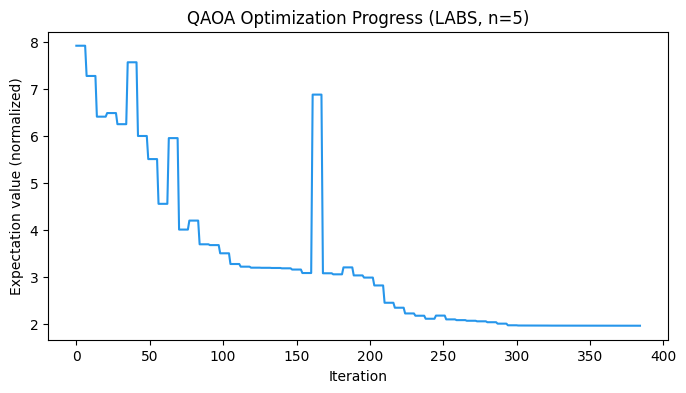

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Expectation value (normalized)")
plt.title("QAOA Optimization Progress (LABS, n=5)")
plt.show()

### Final sampling

We sample once more with the optimized parameters and a larger shot
count. Then we decode against the original `ommx.v1.Instance`, so the
returned `ommx.v1.SampleSet` reports the original QUBO objective
directly. In this QUBO formulation, samples whose auxiliary $z$
variables correctly encode the products $x_i x_{i+k+1}$ incur no
penalty, and the objective equals the LABS energy
$E(\boldsymbol{s}) = \sum_k c_k^2$. Samples that violate the
implicit $z = x_i x_{i+k+1}$ relation pay an additive penalty
proportional to the placeholder $P$ built into the instance.

In [9]:
def evaluate_with_ommx(
    sample_result, spin_model: BinaryModel, ommx_instance: ommx.v1.Instance
) -> ommx.v1.SampleSet:
    """Decode SPIN samples, flip to BINARY, and evaluate against the OMMX instance."""
    spin_ss = spin_model.decode_from_sampleresult(sample_result)
    ommx_samples = ommx.v1.Samples({})
    next_id = 0
    for sample, occ in zip(spin_ss.samples, spin_ss.num_occurrences):
        if occ <= 0:
            continue
        # SPIN (+/-1) -> BINARY (0/1): x = (1 - s) / 2
        binary_state = {idx: (1 - val) // 2 for idx, val in sample.items()}
        sample_ids = list(range(next_id, next_id + occ))
        next_id += occ
        ommx_samples.append(
            sample_ids,
            ommx.v1.State({idx: float(val) for idx, val in binary_state.items()}),
        )
    return ommx_instance.evaluate_samples(ommx_samples)


gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])
final_shots = 256 if docs_test_mode else 4096

final_result = sampling_executable.sample(
    executor,
    shots=final_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()
qaoa_sample_set = evaluate_with_ommx(final_result, spin_model, instance)

qaoa_summary = qaoa_sample_set.summary
qaoa_best = qaoa_sample_set.best_feasible
qaoa_best_E = int(round(qaoa_best.objective))
ref_E = int(reference_solution.objective)

print(f"Shots:                {len(qaoa_summary)}")
print(f"QAOA best objective:  {qaoa_best_E}")
print(f"Reference E*:         {ref_E}")

Shots:                4096
QAOA best objective:  2
Reference E*:         2


### Distribution of objective values

QAOA returns a distribution over bitstrings, not a single answer. The
histogram below shows the QUBO objective of every shot at the
optimized parameters. The red dashed line marks the reference
optimum $E^\star$. Samples on, or just to the right of, that line have
$x$ values that minimize the LABS sum and $z$ values that correctly
encode the products. Samples far to the right pay a penalty for
inconsistent $z$ values.

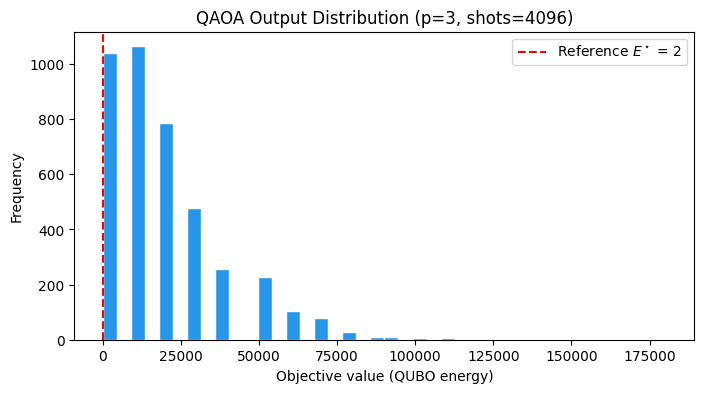

In [10]:
objectives = qaoa_summary["objective"].to_numpy()

plt.figure(figsize=(8, 4))
plt.hist(objectives, bins=40, color="#2696EB", edgecolor="white")
plt.axvline(
    ref_E,
    color="red",
    linestyle="--",
    label=f"Reference $E^\\star$ = {ref_E}",
)
plt.xlabel("Objective value (QUBO energy)")
plt.ylabel("Frequency")
plt.title(f"QAOA Output Distribution (p={p}, shots={final_shots})")
plt.legend()
plt.show()

## Classical baseline: SCIP via the OMMX adapter

**SCIP** is a branch-and-bound-based MILP/QUBO solver that can certify
an optimum when the solve completes. The same `ommx.v1.Instance`
is consumed by
`ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve`, which hands the
problem to SCIP via PySCIPOpt and returns an `ommx.v1.Solution`
evaluated against the *original* instance. Its `.objective` is
therefore directly comparable to QAOA's.

In [11]:
import ommx_pyscipopt_adapter

t0 = time.perf_counter()
scip_solution = ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve(instance)
scip_solve_time = time.perf_counter() - t0

scip_E = int(round(scip_solution.objective))
print(f"SCIP E(s):    {scip_E}")
print(f"SCIP feasible: {scip_solution.feasible}")
print(f"Wall time:    {scip_solve_time:.3f} s")

SCIP E(s):    2
SCIP feasible: True
Wall time:    0.129 s


## Results comparison

SCIP returns a single optimum deterministically, while QAOA returns a
*distribution* over bitstrings. We report QAOA's **best shot**
(the lowest-objective bitstring seen across all samples) and its
**hit rate** on the reference optimum (the fraction of shots that
achieved $E^\star$).

In [12]:
# Hit rate: fraction of shots that achieved the reference optimum.
hit_rate = float((qaoa_summary["objective"].round().astype(int) == ref_E).mean())

print(f"{'Solver':<22} {'E(s)':>8} {'Time (s)':>12}")
print("-" * 46)
print(f"{'Reference (bundled)':<22} {ref_E:>8} {'-':>12}")
print(f"{'SCIP (classical)':<22} {scip_E:>8} {scip_solve_time:>12.3f}")
print(f"{'QAOA (best shot)':<22} {qaoa_best_E:>8} {qaoa_optimize_time:>12.2f}")
print()
print(f"QAOA hit rate on E* = {ref_E}: {hit_rate:.1%}  ({final_shots} shots)")

Solver                     E(s)     Time (s)
----------------------------------------------
Reference (bundled)           2            -
SCIP (classical)              2        0.129
QAOA (best shot)              2         4.54

QAOA hit rate on E* = 2: 4.6%  (4096 shots)


Two observations make this benchmark meaningful:

1. **Optimum.** Both SCIP and the best QAOA shot reach the reference
   optimum $E^\star = 2$, so QAOA is *capable* of finding the optimal
   sequence at $n = 5$ with only $p = 3$ layers.
2. **Concentration.** QAOA's value lies in concentrating sampling
   probability on low-energy bitstrings. The hit rate above, together
   with the left tail of the histogram, is the quantitative version of
   that statement.

The wall-time column shows the *shape* of the comparison, not a
head-to-head verdict. SCIP runs directly against the QUBO on the CPU,
while the QAOA timing covers the full classical-quantum
optimization loop on a state-vector simulator. As $n$ grows, the
*qualitative* trade-off between exact branch-and-bound and
polynomial-depth heuristic circuits is what makes benchmark datasets
like OMMX Quantum Benchmarks useful for evaluating both sides.

## Summary

In this tutorial we:

1. Loaded a LABS instance straight from the **OMMX Quantum Benchmarks**
   dataset as an `ommx.v1.Instance`.
2. Extracted the QUBO with `Instance.to_qubo()`, wrapped it in a
   `BinaryModel`, switched to the spin domain, and ran a hand-written
   QAOA ansatz (using `@qkernel`) against it through
   `QiskitTranspiler` + `AerSimulator`.
3. Compared the QAOA output (best shot, hit rate, sampling
   distribution) against SCIP via
   `ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve` on the *same*
   instance, plus the reference optimum bundled with the benchmark.

The pattern generalizes: any other QOBLIB dataset
(`Marketsplit`, `IndependentSet`, `Network`, …) plugs into the same
pipeline: load with the corresponding dataset class, extract the
QUBO via `Instance.to_qubo()`, and reuse the same `BinaryModel` +
QAOA ansatz + transpile loop. Larger instances will
eventually outgrow local simulators, at which point the same
`executable` can be re-targeted to other Qamomile backends
(`QuriPartsTranspiler`, `CudaqTranspiler`, …) or real hardware.